In [8]:
# %%
import sys
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
from pathlib import Path
from tqdm import tqdm
from collections import Counter

# 1. Add lingbot-vision to your system path (Adjust the path if it's different on your machine)
sys.path.insert(0, r"D:\GermanSVD\lingbot-vision")
from lingbot_vision import load_pretrained_backbone

# 2. Paths to your generated spectrogram dataset
DATA_ROOT = Path("spectrogram_dataset")  # Adjust this path to where your dataset is located
TRAIN_DIR = DATA_ROOT / "train"
VAL_DIR = DATA_ROOT / "val"
TEST_DIR = DATA_ROOT / "test"

# 3. Hyperparameters
BATCH_SIZE = 32
HEAD_WARMUP_EPOCHS = 5      # phase 1: train only the head, backbone still frozen
FINETUNE_EPOCHS = 30        # phase 2: unfreeze backbone, fine-tune end-to-end
HEAD_LR = 1e-3              # LR for the classifier head (both phases)
BACKBONE_LR = 2e-5          # LR for the backbone during phase 2 -- must be much lower
VARIANT = "small"           # Matches the 'small' variant (embed_dim=384)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
LABEL_SMOOTHING = 0.1
GRAD_CLIP_NORM = 1.0
UNFREEZE_LAST_N_BLOCKS = None  # None = unfreeze the whole backbone; set an int (e.g. 4)
                                # to only unfreeze the last N transformer blocks if you
                                # have a small dataset and full fine-tuning overfits.

print(f"Using device: {DEVICE}")

# %%
# 1. Find ALL unique classes across train, val, and test to ensure consistent label mapping
ALL_CLASSES = set()
for split in ['train', 'val', 'test']:
    split_dir = DATA_ROOT / split
    if split_dir.exists():
        for d in split_dir.iterdir():
            if d.is_dir():
                ALL_CLASSES.add(d.name)
ALL_CLASSES = sorted(list(ALL_CLASSES))
print(f"Total unique classes found across all splits: {len(ALL_CLASSES)}")


class SpectrogramDataset(Dataset):
    def __init__(self, root_dir, classes, transform=None):
        self.root_dir = Path(root_dir)
        self.transform = transform

        self.classes = classes
        self.class_to_idx = {c: i for i, c in enumerate(classes)}
        self.samples = []

        for cls_name in self.classes:
            cls_dir = self.root_dir / cls_name
            if not cls_dir.exists():
                continue

            # Collect all images directly inside the class folder
            for img_path in cls_dir.glob("*"):
                if img_path.suffix.lower() in {".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff"}:
                    self.samples.append(
                        (str(img_path), self.class_to_idx[cls_name])
                    )

        print(f"{self.root_dir.name}: {len(self.samples)} images")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, label

# Transforms (LingBot-Vision's own preprocessing uses ImageNet stats; 224x224 is fine
# since it's a multiple of the ViT-S/16 patch size -> 14x14 = 196 patch tokens)
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    # RandomErasing operates on tensors, so it must come after ToTensor()/Normalize(),
    # not before -- a touch of masking helps a fine-tuned ViT generalize on small datasets.
    transforms.RandomErasing(p=0.2, scale=(0.02, 0.08))
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Pass the global ALL_CLASSES list to the datasets
train_dataset = SpectrogramDataset(TRAIN_DIR, classes=ALL_CLASSES, transform=train_transform)
val_dataset = SpectrogramDataset(VAL_DIR, classes=ALL_CLASSES, transform=val_transform)

print(f"Training samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)


# %%
class LingBotClassifier(nn.Module):
    def __init__(self, num_classes, variant="small", device="cuda"):
        super().__init__()
        # load_pretrained_backbone ALWAYS returns the backbone with every parameter
        # frozen (requires_grad_(False) is set inside the loader itself). Calling
        # model.train() later does NOT undo this -- you must explicitly re-enable
        # requires_grad on the parameters you want to fine-tune. See set_backbone_trainable().
        self.backbone, self.embed_dim = load_pretrained_backbone(
            variant=variant,
            device=device,
            dtype=torch.float32
        )

        # A slightly deeper head than a single Linear gives the (now-trainable)
        # backbone features a bit more room, and dropout guards against overfitting
        # once you unfreeze a 21M-parameter backbone on a small dataset.
        self.classifier = nn.Sequential(
            nn.LayerNorm(self.embed_dim),
            nn.Dropout(0.2),
            nn.Linear(self.embed_dim, num_classes)
        )

    def forward(self, x):
        # self.backbone(x) with default is_training=False returns
        # self.head(x_norm_clstoken) where head is nn.Identity() -> the CLS embedding,
        # shape (batch_size, embed_dim). This part of your original code was correct.
        features = self.backbone(x)
        logits = self.classifier(features)
        return logits

    def set_backbone_trainable(self, trainable: bool, unfreeze_last_n_blocks=None):
        """Explicitly override the freeze that load_pretrained_backbone applies.

        trainable=False -> everything frozen (linear-probe phase).
        trainable=True, unfreeze_last_n_blocks=None -> unfreeze the whole backbone.
        trainable=True, unfreeze_last_n_blocks=N -> only unfreeze the last N
            transformer blocks (cheaper, less prone to overfitting on small data).
        """
        for p in self.backbone.parameters():
            p.requires_grad_(False)

        if not trainable:
            self.backbone.eval()
            return

        if unfreeze_last_n_blocks is None:
            for p in self.backbone.parameters():
                p.requires_grad_(True)
        else:
            # Most ViT implementations expose the transformer stack as `.blocks`
            if not hasattr(self.backbone, "blocks"):
                raise AttributeError(
                    "Backbone has no `.blocks` attribute -- inspect the model "
                    "structure (print(self.backbone)) to find the right attribute "
                    "name for partial unfreezing, or pass unfreeze_last_n_blocks=None."
                )
            blocks_to_unfreeze = self.backbone.blocks[-unfreeze_last_n_blocks:]
            for block in blocks_to_unfreeze:
                for p in block.parameters():
                    p.requires_grad_(True)
            # Also unfreeze the final norm, since it directly feeds the CLS token
            if hasattr(self.backbone, "norm"):
                for p in self.backbone.norm.parameters():
                    p.requires_grad_(True)

        self.backbone.train()


# %%
# 1. Count how many images belong to each class in the training set
class_counts = Counter([label for _, label in train_dataset.samples])
num_classes = len(ALL_CLASSES)

# 2. Calculate inverse frequency weights
weights = [1.0 / class_counts.get(i, 1) for i in range(num_classes)]

# 3. Normalize weights
weights = [w * num_classes / sum(weights) for w in weights]

# 4. Convert to tensor and move to GPU
class_weights = torch.tensor(weights, dtype=torch.float32).to(DEVICE)
print(f"Applied class weights for {num_classes} classes. (Rare diseases now have higher priority)")

# Initialize model. The backbone comes back frozen from load_pretrained_backbone --
# that's the correct starting point for phase 1 (head warmup).
model = LingBotClassifier(num_classes=num_classes, variant=VARIANT, device=DEVICE).to(DEVICE)
model.set_backbone_trainable(False)

criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=LABEL_SMOOTHING)


def make_optimizer(model, backbone_trainable):
    """Discriminative learning rates: head always trains faster than the backbone."""
    param_groups = [{"params": model.classifier.parameters(), "lr": HEAD_LR}]
    if backbone_trainable:
        trainable_backbone_params = [p for p in model.backbone.parameters() if p.requires_grad]
        if trainable_backbone_params:
            param_groups.append({"params": trainable_backbone_params, "lr": BACKBONE_LR})
    return optim.AdamW(param_groups, weight_decay=1e-4)


def run_epoch(model, loader, criterion, optimizer=None, desc="Train"):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()
    # Even in "train mode" for phase 1, keep frozen backbone submodules truly in eval
    # so their (batchnorm-like) layers don't drift; harmless once the backbone is unfrozen.

    total_loss, correct, total = 0.0, 0, 0
    pbar = tqdm(loader, desc=desc)
    context = torch.enable_grad() if is_train else torch.no_grad()
    with context:
        for images, labels in pbar:
            images, labels = images.to(DEVICE), labels.to(DEVICE)

            if is_train:
                optimizer.zero_grad()

            outputs = model(images)
            loss = criterion(outputs, labels)

            if is_train:
                loss.backward()
                nn.utils.clip_grad_norm_(
                    [p for g in optimizer.param_groups for p in g["params"]], GRAD_CLIP_NORM
                )
                optimizer.step()

            total_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
            pbar.set_postfix({'loss': f"{total_loss/total:.4f}", 'acc': f"{100.*correct/total:.2f}%"})

    return total_loss / total, 100. * correct / total


# %%
# ---------------- PHASE 1: head warmup (backbone frozen) ----------------
print("\n===== Phase 1: warming up the classifier head (backbone frozen) =====\n")
optimizer = make_optimizer(model, backbone_trainable=False)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=HEAD_WARMUP_EPOCHS)

best_val_acc = 0.0
for epoch in range(HEAD_WARMUP_EPOCHS):
    train_loss, train_acc = run_epoch(model, train_loader, criterion, optimizer, desc=f"Epoch {epoch+1}/{HEAD_WARMUP_EPOCHS} [Head Train]")
    val_loss, val_acc = run_epoch(model, val_loader, criterion, optimizer=None, desc=f"Epoch {epoch+1}/{HEAD_WARMUP_EPOCHS} [Val]")
    scheduler.step()
    print(f"Epoch {epoch+1} Summary: Train Acc: {train_acc:.2f}% | Val Acc: {val_acc:.2f}%\n")
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "best_lingbot_svd.pth")
        print(f"--> Saved new best model with Val Acc: {val_acc:.2f}%\n")

# %%
# ---------------- PHASE 2: full fine-tuning (backbone unfrozen) ----------------
print("\n===== Phase 2: fine-tuning with backbone unfrozen =====\n")
model.set_backbone_trainable(True, unfreeze_last_n_blocks=UNFREEZE_LAST_N_BLOCKS)
optimizer = make_optimizer(model, backbone_trainable=True)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=FINETUNE_EPOCHS)

patience, patience_counter = 7, 0
for epoch in range(FINETUNE_EPOCHS):
    train_loss, train_acc = run_epoch(model, train_loader, criterion, optimizer, desc=f"Epoch {epoch+1}/{FINETUNE_EPOCHS} [FT Train]")
    val_loss, val_acc = run_epoch(model, val_loader, criterion, optimizer=None, desc=f"Epoch {epoch+1}/{FINETUNE_EPOCHS} [Val]")
    scheduler.step()
    print(f"Epoch {epoch+1} Summary: Train Acc: {train_acc:.2f}% | Val Acc: {val_acc:.2f}%\n")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        patience_counter = 0
        torch.save(model.state_dict(), "best_lingbot_svd.pth")
        print(f"--> Saved new best model with Val Acc: {val_acc:.2f}%\n")
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"Early stopping: no val improvement for {patience} epochs.")
            break

# %%
# Load the best model weights

# %%

Using device: cuda
Total unique classes found across all splits: 4
train: 1006 images
val: 217 images
Training samples: 1006
Validation samples: 217
Applied class weights for 4 classes. (Rare diseases now have higher priority)
[lingbot_vision] arch=vit_small impl=lbot_vision embed_dim=384 loaded=188 missing=0 unexpected=0

===== Phase 1: warming up the classifier head (backbone frozen) =====



Epoch 1/5 [Val]: 100%|██████████| 7/7 [00:03<00:00,  1.89it/s, loss=0.9679, acc=71.43%]


Epoch 1 Summary: Train Acc: 47.81% | Val Acc: 71.43%

--> Saved new best model with Val Acc: 71.43%



Epoch 2/5 [Val]: 100%|██████████| 7/7 [00:01<00:00,  4.06it/s, loss=0.8879, acc=76.96%]


Epoch 2 Summary: Train Acc: 66.00% | Val Acc: 76.96%

--> Saved new best model with Val Acc: 76.96%



...

Epoch 14 Summary: Train Acc: 99.80% | Val Acc: 82.95%



Epoch 15/30 [Val]: 100%|██████████| 7/7 [00:02<00:00,  2.60it/s, loss=0.7138, acc=85.25%]


Epoch 15 Summary: Train Acc: 99.80% | Val Acc: 85.25%



Epoch 16/30 [Val]: 100%|██████████| 7/7 [00:01<00:00,  4.64it/s, loss=0.7162, acc=85.25%]

Epoch 16 Summary: Train Acc: 99.80% | Val Acc: 85.25%

Early stopping: no val improvement for 7 epochs.


In [9]:

model.load_state_dict(torch.load("best_lingbot_svd.pth"))
model.eval()

# Setup test dataloader -- must pass classes=ALL_CLASSES, same as train/val,
# or the label indices won't match and accuracy will be meaningless / it will crash.
test_dataset = SpectrogramDataset(TEST_DIR, classes=ALL_CLASSES, transform=val_transform)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

test_correct = 0
test_total = 0

print("Evaluating on Test Set...")
with torch.no_grad():
    for images, labels in tqdm(test_loader, desc="Testing"):
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        outputs = model(images)
        _, predicted = outputs.max(1)
        test_total += labels.size(0)
        test_correct += predicted.eq(labels).sum().item()

print(f"\n🎉 Final Test Accuracy: {100. * test_correct / test_total:.2f}%")


test: 218 images
Evaluating on Test Set...


Testing: 100%|██████████| 7/7 [00:03<00:00,  1.80it/s]


🎉 Final Test Accuracy: 80.28%


Running inference...


100%|██████████| 7/7 [00:01<00:00,  5.85it/s]



Overall Accuracy : 80.28%

Classification Report

              precision    recall  f1-score   support

  Laryngitis     0.7059    0.7500    0.7273        64
 Vox senilis     0.8750    0.7119    0.7850        59
       dysar     0.5278    0.6552    0.5846        29
   parkinson     1.0000    1.0000    1.0000        66

    accuracy                         0.8028       218
   macro avg     0.7772    0.7793    0.7742       218
weighted avg     0.8170    0.8028    0.8065       218



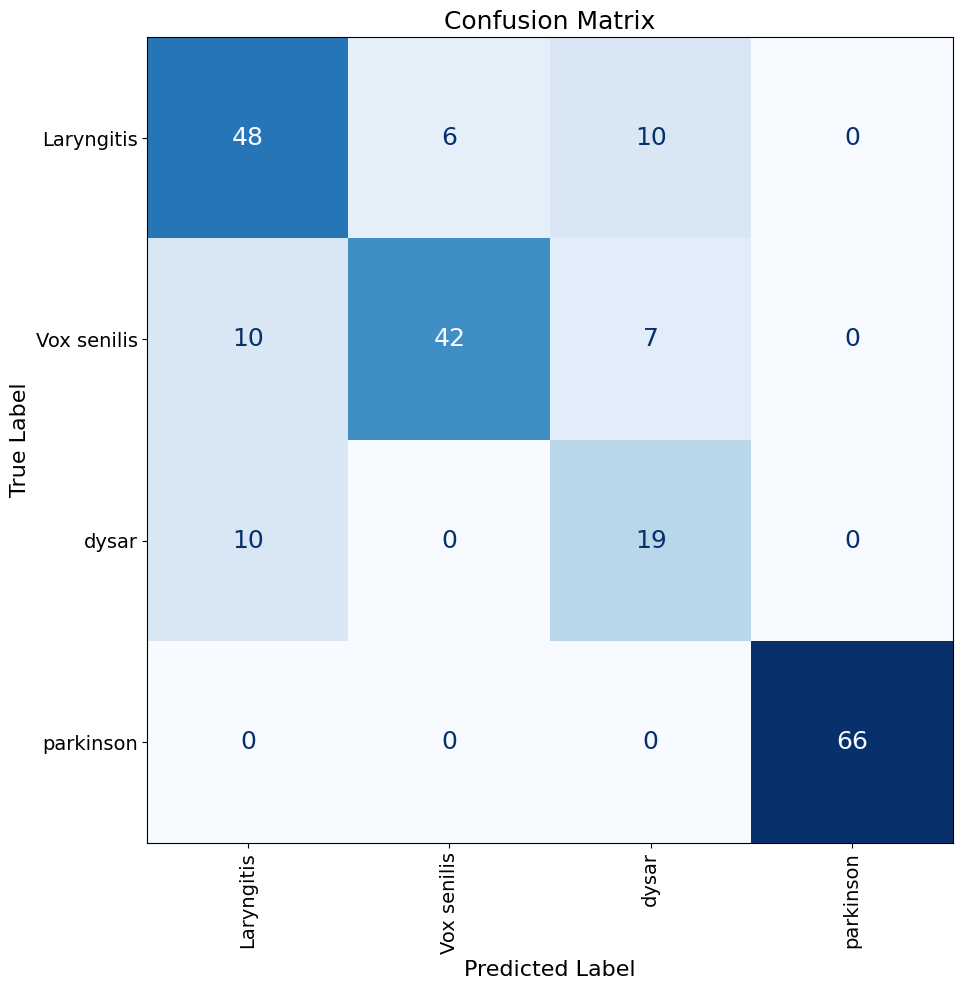

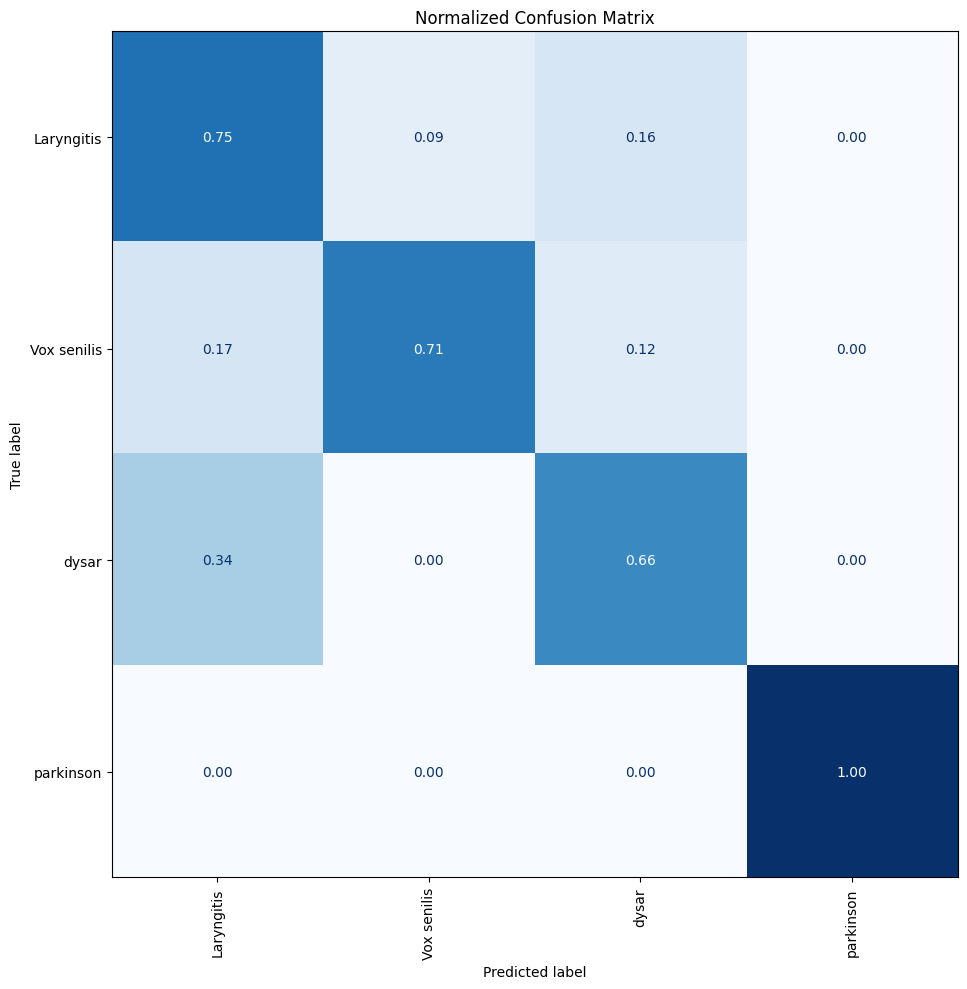


Per-class Metrics

Laryngitis                 P=0.706  R=0.750  F1=0.727  N=64
Vox senilis                P=0.875  R=0.712  F1=0.785  N=59
dysar                      P=0.528  R=0.655  F1=0.585  N=29
parkinson                  P=1.000  R=1.000  F1=1.000  N=66


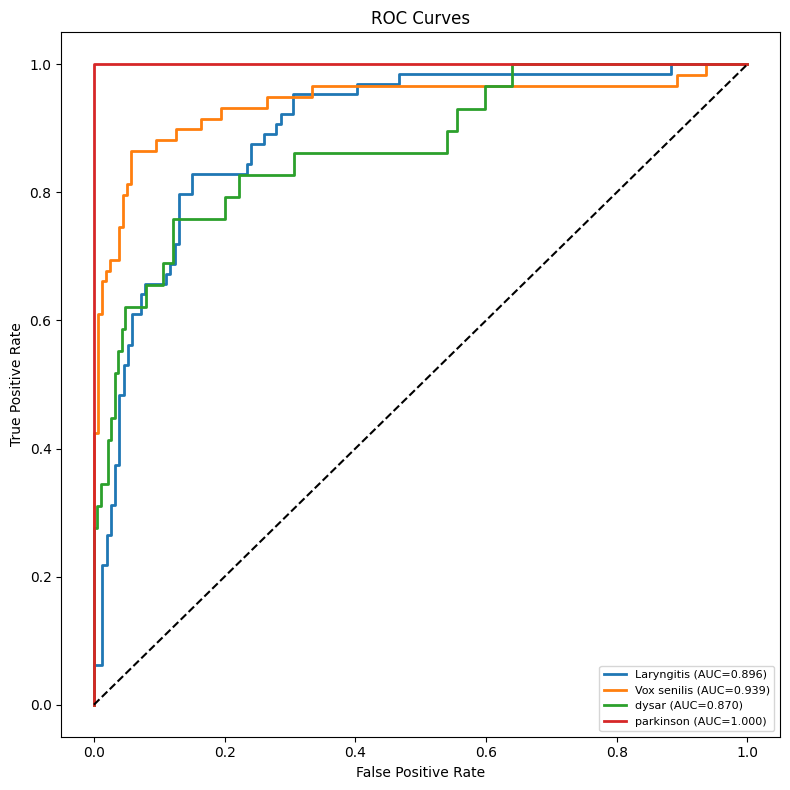

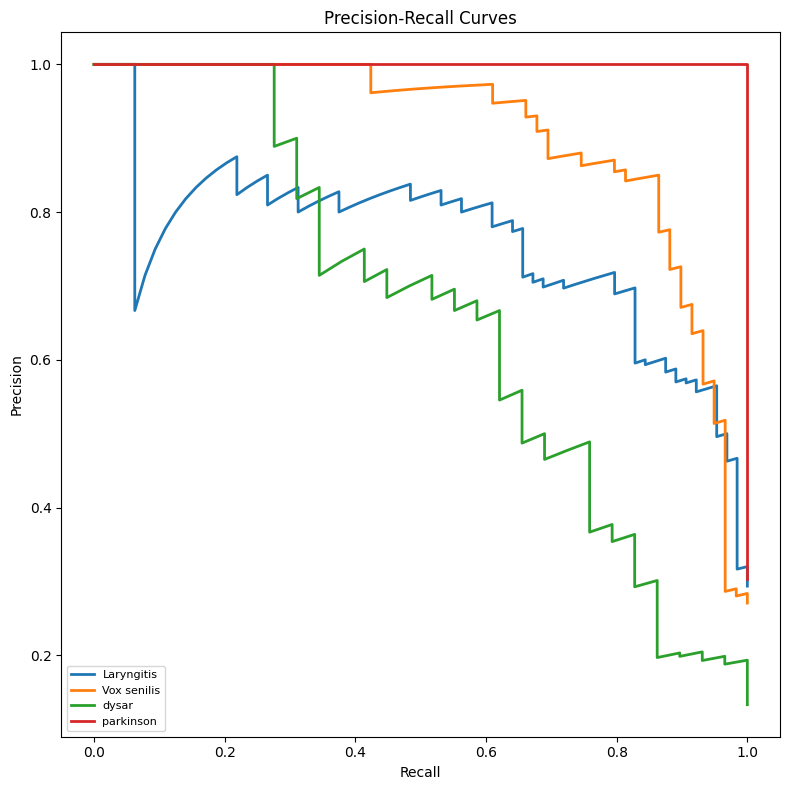


All evaluation plots saved to 'evaluation_results'


In [13]:
# ============================================
# Complete Evaluation on Test Set
# ============================================

import os
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_recall_fscore_support,
    roc_curve,
    auc,
    precision_recall_curve
)

from sklearn.preprocessing import label_binarize
from tqdm import tqdm

SAVE_DIR = "evaluation_results"
os.makedirs(SAVE_DIR, exist_ok=True)

model.eval()

y_true = []
y_pred = []
y_prob = []

print("Running inference...")

with torch.no_grad():
    for images, labels in tqdm(test_loader):
        images = images.to(DEVICE)

        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)

        preds = probs.argmax(dim=1)

        y_true.extend(labels.numpy())
        y_pred.extend(preds.cpu().numpy())
        y_prob.extend(probs.cpu().numpy())

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_prob = np.array(y_prob)

# ============================================
# Accuracy
# ============================================

acc = accuracy_score(y_true, y_pred)
print(f"\nOverall Accuracy : {acc*100:.2f}%")

# ============================================
# Classification Report
# ============================================

report = classification_report(
    y_true,
    y_pred,
    target_names=ALL_CLASSES,
    digits=4
)

print("\nClassification Report\n")
print(report)

with open(os.path.join(SAVE_DIR, "classification_report.txt"), "w") as f:
    f.write(report)

# ============================================
# Confusion Matrix
# ============================================

cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(10, 10))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=ALL_CLASSES
)

disp.plot(
    cmap="Blues",
    xticks_rotation=90,
    ax=ax,
    colorbar=False
)

# Increase the size of the numbers inside the cells
for text in disp.text_.ravel():
    text.set_fontsize(18)   # Change to desired size

plt.title("Confusion Matrix", fontsize=18)
plt.xlabel("Predicted Label", fontsize=16)
plt.ylabel("True Label", fontsize=16)

# Increase tick label size
ax.tick_params(axis='both', labelsize=14)

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "confusion_matrix.png"), dpi=800)
plt.show()

# ============================================
# Normalized Confusion Matrix
# ============================================

cm_norm = confusion_matrix(
    y_true,
    y_pred,
    normalize="true"
)

fig, ax = plt.subplots(figsize=(10,10))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_norm,
    display_labels=ALL_CLASSES
)

disp.plot(
    cmap="Blues",
    xticks_rotation=90,
    ax=ax,
    values_format=".2f",
    colorbar=False
)

plt.title("Normalized Confusion Matrix")
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR,"confusion_matrix_normalized.png"), dpi=300)
plt.show()

# ============================================
# Precision Recall F1
# ============================================

precision, recall, f1, support = precision_recall_fscore_support(
    y_true,
    y_pred
)

print("\nPer-class Metrics\n")

for i, cls in enumerate(ALL_CLASSES):
    print(f"{cls:25s}  "
          f"P={precision[i]:.3f}  "
          f"R={recall[i]:.3f}  "
          f"F1={f1[i]:.3f}  "
          f"N={support[i]}")

# ============================================
# ROC Curves
# ============================================

num_classes = len(ALL_CLASSES)

y_true_bin = label_binarize(
    y_true,
    classes=np.arange(num_classes)
)

plt.figure(figsize=(8,8))

for i in range(num_classes):

    fpr, tpr, _ = roc_curve(
        y_true_bin[:,i],
        y_prob[:,i]
    )

    roc_auc = auc(fpr,tpr)

    plt.plot(
        fpr,
        tpr,
        lw=2,
        label=f"{ALL_CLASSES[i]} (AUC={roc_auc:.3f})"
    )

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend(fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR,"roc_curves.png"), dpi=800)
plt.show()

# ============================================
# Precision Recall Curves
# ============================================

plt.figure(figsize=(8,8))

for i in range(num_classes):

    p,r,_ = precision_recall_curve(
        y_true_bin[:,i],
        y_prob[:,i]
    )

    plt.plot(
        r,
        p,
        lw=2,
        label=ALL_CLASSES[i]
    )

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curves")
plt.legend(fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR,"precision_recall_curves.png"), dpi=300)
plt.show()

print(f"\nAll evaluation plots saved to '{SAVE_DIR}'")